In [1]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline

15:39:37 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=28948;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=977695;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=280091;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=52990;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=948571;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=332363;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

15:39:38 INFO      Starting 3ML!                                                                     ]8;id=147412;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=138185;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=136876;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=919349;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=292167;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=523894;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

15:39:39 WARNING   No fermitools installed                                              ]8;id=263605;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=186799;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=993061;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=640473;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=418788;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=192472;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=626475;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=995753;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

In [ ]:
multiplier_4151 = 1
multiplier_1068 = 1

# Exposure changes count statistics, not the intrinsic spectra plotted below.
exposure_4151 = multiplier_4151 * 3
exposure_1068 = multiplier_1068 * 3

norm_nt = 0.30

# Source Model Plots

## Cutoff Power Law (Thermal)

### NGC 4151 Faint

In [ ]:
K_inj = 0.035 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.81

spectrum_inj_faint = Cutoff_powerlaw()

spectrum_inj_faint.K.value = K_inj.value
spectrum_inj_faint.piv.value = piv_inj.value
spectrum_inj_faint.xc.value = xc_inj.value
spectrum_inj_faint.index.value = index_inj

spectrum_inj_faint.K.unit = K_inj.unit
spectrum_inj_faint.piv.unit = piv_inj.unit
spectrum_inj_faint.xc.unit = xc_inj.unit

print(spectrum_inj_faint.evaluate_at(200))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_faint).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_faint.K.value
    * (200.0 / spectrum_inj_faint.piv.value) ** spectrum_inj_faint.index.value
)

print(K_inj_at_fit_pivot)

### NGC 4151 Bright

In [ ]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1 * u.keV
xc_inj = 264. * u.keV
index_inj = -1.71

spectrum_inj_bright = Cutoff_powerlaw()

spectrum_inj_bright.K.value = K_inj.value
spectrum_inj_bright.piv.value = piv_inj.value
spectrum_inj_bright.xc.value = xc_inj.value
spectrum_inj_bright.index.value = index_inj

spectrum_inj_bright.K.unit = K_inj.unit
spectrum_inj_bright.piv.unit = piv_inj.unit
spectrum_inj_bright.xc.unit = xc_inj.unit

print(spectrum_inj_bright.evaluate_at(200))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_bright).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_bright.K.value
    * (200.0 / spectrum_inj_bright.piv.value) ** spectrum_inj_bright.index.value
)

print(K_inj_at_fit_pivot)

### Case 2

#### NGC 4151 (200 keV)

In [ ]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [ ]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

#### NGC 4151 (200 keV)

In [45]:
def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = norm_nt*spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec200_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec200,
    spectrum_inj_ec200_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec200.evaluate_at(E), 100.0, 10000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec200_PL.evaluate_at(E), 100.0, 10000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200 + spectrum_inj_ec200_PL).evaluate_at(E),
    100.0,
    10000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200.K.value
    * (200.0 / spectrum_inj_ec200.piv.value) ** spectrum_inj_ec200.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  1.5563796348962473e-06 1 / (keV s cm2)
5.187932116320825e-06
1.5563796348962477e-06
Linking K ratio 0.11036383235143273
Flux ratio at 200 keV 0.30000000000000004
Non-thermal energy flux:  1.929115844558418e-10 erg / (s cm2)
Total energy flux:  6.959336905294415e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  2.6075266941200383
Non-thermal energy flux percentage:  0.27719822603944
energy_flux:  6.959336905294416e-10 erg / (s cm2)
energy_flux_err:  5.654736853101171e-18 erg / (s cm2)
1.4102261599073975e-05


In [34]:
# Replace the hard step with a continuous broken power law.
# Below 200 keV the positive index suppresses the tail smoothly; above
# 200 keV the model retains the original -3.8 non-thermal slope.
from astromodels import Broken_powerlaw

spectrum_inj_ec200_PL_unbroken = spectrum_inj_ec200_PL

break_energy = 200.0 * u.keV
index_below_break = -2
index_above_break = spectrum_inj_ec200_PL_unbroken.index.value
K_at_break = (
    spectrum_inj_ec200_PL_unbroken.evaluate_at(break_energy.value)
    / u.cm / u.cm / u.s / u.keV
)

spectrum_inj_ec200_BPL = Broken_powerlaw()
spectrum_inj_ec200_BPL.K.value = K_at_break.value
spectrum_inj_ec200_BPL.xb.value = break_energy.value
spectrum_inj_ec200_BPL.piv.value = break_energy.value
spectrum_inj_ec200_BPL.alpha.value = index_below_break
spectrum_inj_ec200_BPL.beta.value = index_above_break
spectrum_inj_ec200_BPL.K.unit = K_at_break.unit
spectrum_inj_ec200_BPL.xb.unit = break_energy.unit
spectrum_inj_ec200_BPL.piv.unit = break_energy.unit

# Keep the existing variable name so the plotting cells below use the BPL.
spectrum_inj_ec200_PL = spectrum_inj_ec200_BPL
spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec200_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec200,
    spectrum_inj_ec200_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec200.evaluate_at(E), 200.0, 5000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec200_PL.evaluate_at(E), 200.0, 5000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200 + spectrum_inj_ec200_PL).evaluate_at(E),
    200.0,
    10000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200.K.value
    * (200.0 / spectrum_inj_ec200.piv.value) ** spectrum_inj_ec200.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  2.07517284652833e-06 1 / (keV s cm2)
5.187932116320825e-06
2.07517284652833e-06
Linking K ratio 0.14715177646857694
Flux ratio at 200 keV 0.4
Non-thermal energy flux:  7.365925858657928e-11 erg / (s cm2)
Total energy flux:  2.9621824882168514e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  3.021466608620686
Non-thermal energy flux percentage:  0.24866549876513527
energy_flux:  2.963786632089244e-10 erg / (s cm2)
energy_flux_err:  1.6294765903334318e-18 erg / (s cm2)
1.4102261599073975e-05


#### NGC 4151 (1000 keV)

In [39]:
K_inj = spectrum_inj_ec200_PL.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_ec1000_PL = Powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print("K_inj: ", K_inj)
print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec1000 = spectrum_inj_ec1000_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec1000,
    spectrum_inj_ec1000_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec1000)
print("Flux ratio at 200 keV", spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec1000.evaluate_at(E), 200.0, 5000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec1000_PL.evaluate_at(E), 200.0, 5000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec1000 + spectrum_inj_ec1000_PL).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec1000.K.value
    * (200.0 / spectrum_inj_ec1000.piv.value) ** spectrum_inj_ec1000.index.value
)

print(K_inj_at_fit_pivot)

K_inj:  1.5563796348962477e-06 1 / (keV s cm2)
1.1545955259112548e-05
1.5563796348962477e-06
Linking K ratio 0.11036383235143273
Flux ratio at 200 keV 0.1347986892351664
Non-thermal energy flux:  5.5244443939934455e-11 erg / (s cm2)
Total energy flux:  1.4745198296456102e-09 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  25.690825800487904
Non-thermal energy flux percentage:  0.03746605696934713
energy_flux:  1.4745198296456102e-09 erg / (s cm2)
energy_flux_err:  6.160567581143991e-19 erg / (s cm2)
1.4102261599073975e-05


### Case 3

#### NGC 4151 (200 keV)

In [ ]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200_testa = Cutoff_powerlaw()

spectrum_inj_ec200_testa.K.value = K_inj.value
spectrum_inj_ec200_testa.piv.value = piv_inj.value
spectrum_inj_ec200_testa.xc.value = xc_inj.value
spectrum_inj_ec200_testa.index.value = index_inj

spectrum_inj_ec200_testa.K.unit = K_inj.unit
spectrum_inj_ec200_testa.piv.unit = piv_inj.unit
spectrum_inj_ec200_testa.xc.unit = xc_inj.unit

#### NGC 4151 (200 keV) Non-thermal cutoff

In [41]:
def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = 0.1*spectrum_inj_ec200_testa.evaluate_at(1) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
index_inj = -1.7
cutoff_inj = 2000. * u.keV

spectrum_inj_ec200_PL_testa = Cutoff_powerlaw()

spectrum_inj_ec200_PL_testa.K.value = K_inj.value
spectrum_inj_ec200_PL_testa.piv.value = piv_inj.value
spectrum_inj_ec200_PL_testa.index.value = index_inj
spectrum_inj_ec200_PL_testa.xc.value = cutoff_inj.value

spectrum_inj_ec200_PL_testa.K.unit = K_inj.unit
spectrum_inj_ec200_PL_testa.piv.unit = piv_inj.unit
spectrum_inj_ec200_PL_testa.xc.unit = cutoff_inj.unit

spectrum_inj_ec200_testa_total = spectrum_inj_ec200_testa + spectrum_inj_ec200_PL_testa

print(spectrum_inj_ec200_testa.evaluate_at(200))
print(spectrum_inj_ec200_PL_testa.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec200_PL_testa.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec200_testa,
    spectrum_inj_ec200_PL_testa.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec200_PL_testa.evaluate_at(200)/spectrum_inj_ec200_testa.evaluate_at(200))
print("="*40)
energy_flux_th_kev, _ = quad(lambda E: E * spectrum_inj_ec200_testa.evaluate_at(E), 200.0, 5000.0)
energy_flux_nth_kev, _ = quad(lambda E: E * spectrum_inj_ec200_PL_testa.evaluate_at(E), 200.0, 5000.0)
energy_flux_th = (energy_flux_th_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_nth = (energy_flux_nth_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
print("Non-thermal energy flux: ", energy_flux_nth)
print("Total energy flux: ", energy_flux_th + energy_flux_nth)
print("Thermal - Non-thermal Energy Flux Ratio: ", energy_flux_th/energy_flux_nth)
print("Non-thermal energy flux percentage: ", energy_flux_nth/(energy_flux_th + energy_flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200_testa + spectrum_inj_ec200_PL_testa).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200_testa.K.value
    * (200.0 / spectrum_inj_ec200_testa.piv.value) ** spectrum_inj_ec200_testa.index.value
)

print(K_inj_at_fit_pivot)

5.187932116320825e-06
1.6547765042367583e-06
Linking K ratio 0.09950124791926825
Flux ratio at 200 keV 0.31896649129832716
Non-thermal energy flux:  3.0938412000782587e-10 erg / (s cm2)
Total energy flux:  5.319431102429317e-10 erg / (s cm2)
Thermal - Non-thermal Energy Flux Ratio:  0.7193613887793472
Non-thermal energy flux percentage:  0.5816112927311607
energy_flux:  5.319431102429163e-10 erg / (s cm2)
energy_flux_err:  2.648326826318879e-20 erg / (s cm2)
1.4102261599073975e-05


In [42]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_inj_bright = np.zeros_like(energy)
flux_inj_faint = np.zeros_like(energy)
flux_inj_ec200 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)
flux_inj_ec200_PL = np.zeros_like(energy)
flux_inj_ec1000_PL = np.zeros_like(energy)
flux_inj_ec200_testa = np.zeros_like(energy)
flux_inj_ec200_PL_testa = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_faint[i] = spectrum_inj_faint.evaluate_at(e)
    flux_inj_bright[i] = spectrum_inj_bright.evaluate_at(e)
    flux_inj_ec200[i] = spectrum_inj_ec200.evaluate_at(e)
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)
    flux_inj_ec200_PL[i] = spectrum_inj_ec200_PL.evaluate_at(e)
    flux_inj_ec1000_PL[i] = spectrum_inj_ec1000_PL.evaluate_at(e)
    flux_inj_ec200_testa[i] = spectrum_inj_ec200_testa.evaluate_at(e)
    flux_inj_ec200_PL_testa[i] = spectrum_inj_ec200_PL_testa.evaluate_at(e)

Plot the fitted and injected spectra

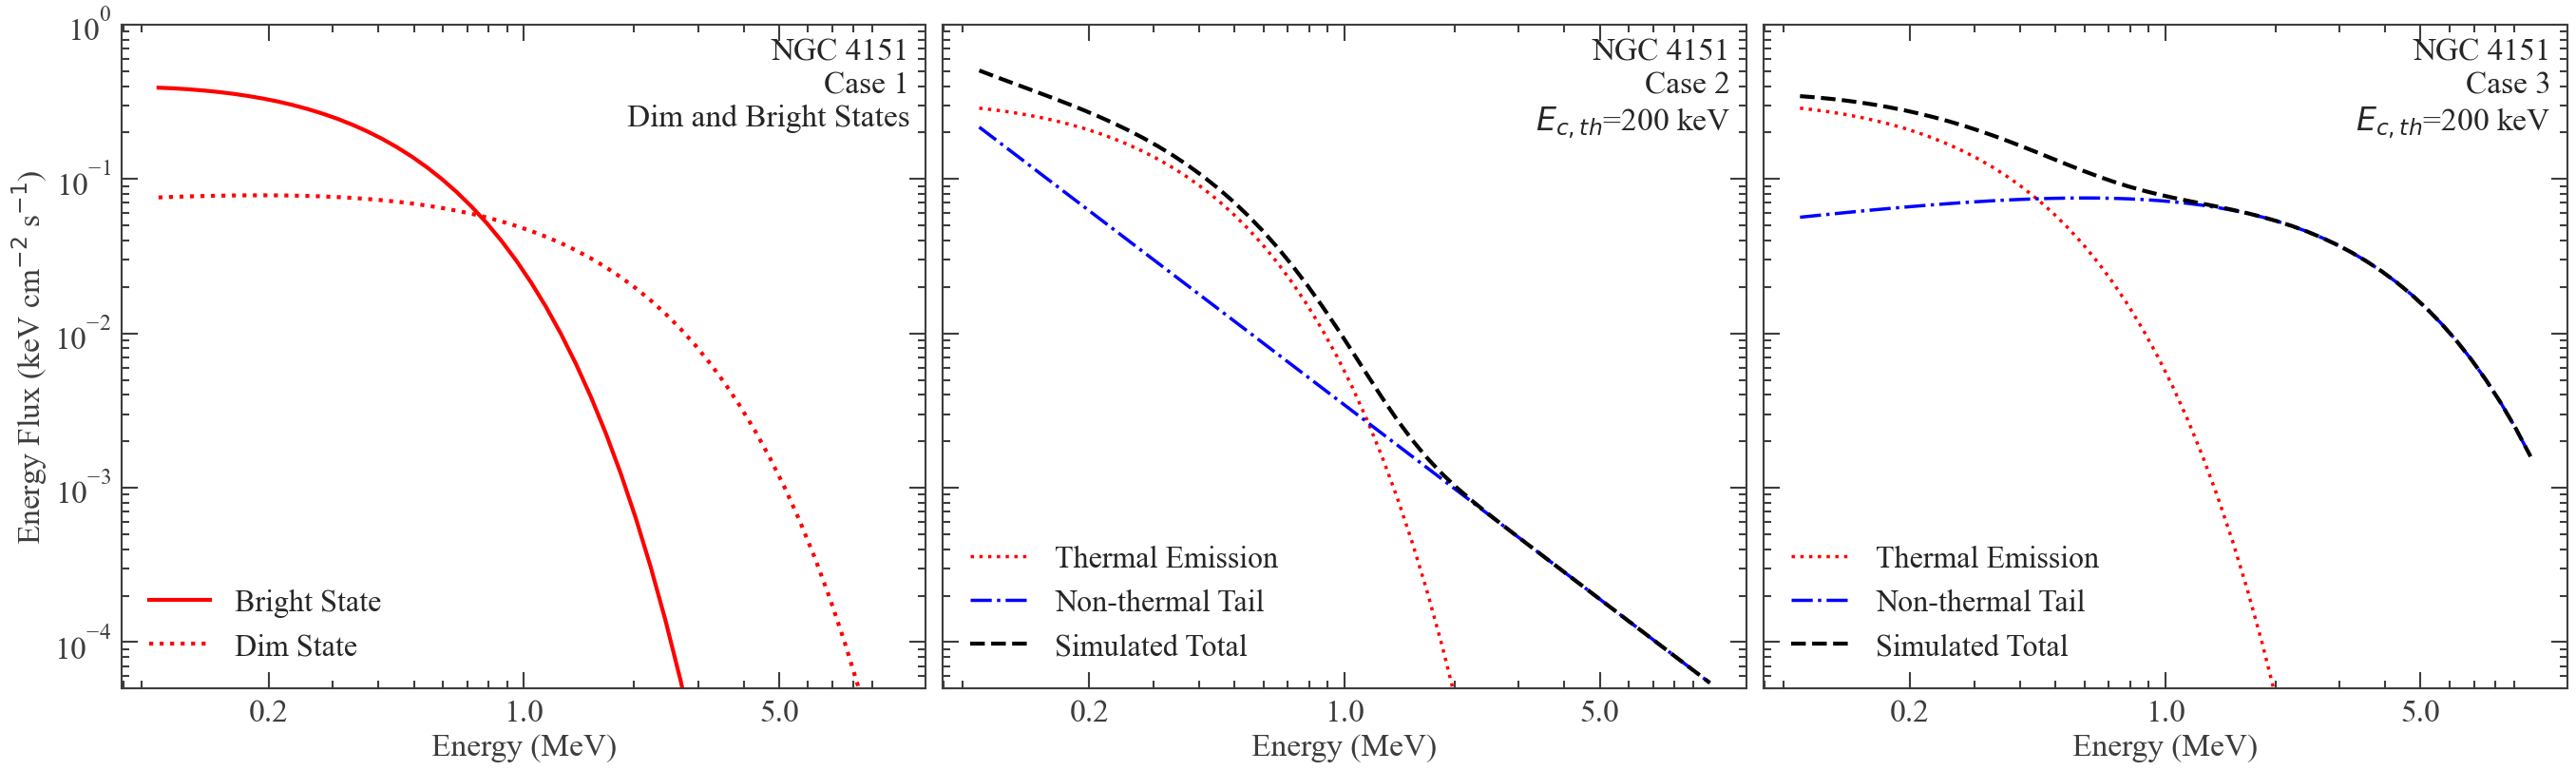

In [43]:
FONT_SIZE=24
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, axes = plt.subplots(1, 3, figsize=(27, 8), sharex=True, sharey=True, constrained_layout=True)

for ax in axes:
    ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
    ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

    ax.spines['right'].set_visible(True)
    ax.spines['top'].set_visible(True)

    ax.set_xscale("log")
    ax.set_yscale("log")
    # ax.set_xlim(160, 6000)
    ax.set_ylim(5e-5, 1)
    ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
    ax.xaxis.set_major_formatter(
        mticker.FixedFormatter(["0.2", "1.0", "5.0"])
    )
    ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)

axes[0].set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

# Panel 1: thermal dim and bright states.
axes[0].plot(energy, energy*energy*flux_inj_bright, color='red', ls='-', lw=3, label='Bright State')
axes[0].plot(energy, energy*energy*flux_inj_faint, color='red', ls=':', lw=3, label='Dim State')
axes[0].text(
    0.98, 0.98,
    'NGC 4151\nCase 1\nDim and Bright States',
    transform=axes[0].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[0].legend(fontsize=23, loc='lower left', frameon=False)

# Panel 2: Case 2 thermal plus power-law non-thermal components.
axes[1].plot(energy, energy*energy*flux_inj_ec200, color='red', ls=':', lw=2.5, label=r'Thermal Emission')
axes[1].plot(energy, energy*energy*flux_inj_ec200_PL, color='blue', ls='-.', lw=2.5, label=r'Non-thermal Tail')
axes[1].plot(energy, energy*energy*(flux_inj_ec200 + flux_inj_ec200_PL), color='black', ls='--', lw=3, label=r'Simulated Total')
# axes[1].plot(energy, energy*energy*flux_inj_ec1000, color='red', ls=':', lw=2.5, label=r'Thermal, $E_c=1000$ keV')
# axes[1].plot(energy, energy*energy*flux_inj_ec1000_PL, color='red', ls='-.', lw=2.5, label=r'Non-thermal, $E_c=1000$ keV')
# axes[1].plot(energy, energy*energy*(flux_inj_ec1000 + flux_inj_ec1000_PL), color='red', ls='-', lw=3, label=r'Total, $E_c=1000$ keV')
axes[1].text(
    0.98, 0.98,
    'NGC 4151\nCase 2\n$E_{c,th}$=200 keV',
    transform=axes[1].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[1].legend(fontsize=23, loc='lower left', frameon=False)

# Panel 3: Case 3 thermal plus cutoff power-law non-thermal component.
axes[2].plot(energy, energy*energy*flux_inj_ec200_testa, color='red', ls=':', lw=2.5, label=r'Thermal Emission')
axes[2].plot(energy, energy*energy*flux_inj_ec200_PL_testa, color='blue', ls='-.', lw=2.5, label=r'Non-thermal Tail')
axes[2].plot(energy, energy*energy*(flux_inj_ec200_testa + flux_inj_ec200_PL_testa), color='black', ls='--', lw=3, label=r'Simulated Total')
axes[2].text(
    0.98, 0.98,
    'NGC 4151\nCase 3\n$E_{c,th}$=200 keV',
    transform=axes[2].transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
axes[2].legend(fontsize=23, loc='lower left', frameon=False)

save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_DimBright_Case2_Case3_Three_Panel.pdf"
# plt.savefig(save_path, bbox_inches='tight')